In [3]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler



In [5]:
data=pd.read_csv('../../data/processed/data_selected.csv')
data.head()

,Date,GARCH_Vol,KOSDAQ,KOSPI 200 Low,Shanghai Comp,GJR_GARCH_Vol,GJR_VaR_95,Gold Spot,TOPIX,JPY/KRW,KOSPI 200 Close,NASDAQ,KODEX 200,Signal2_Sell,KOSPI 200_RSI14,Actual_Return(%),Risk_Label
0,2009-04-17,1.432045,483.799988,169.710007,2503.935059,1.426891,-2.246073,867.400024,875.0,13.371,171.330002,1673.069946,17370.0,0,63.873746,-0.233192,0
1,2009-04-20,1.378327,491.940002,169.039993,2557.456055,1.379095,-2.169582,887.000000,876.0,13.536,172.300003,1608.209961,17480.0,0,76.439644,0.564563,0
2,2009-04-21,1.332280,497.190002,167.660004,2535.827881,1.312454,-2.062932,882.099976,855.0,13.727,171.960007,1643.849976,17480.0,0,74.958299,-0.197523,0
3,2009-04-22,1.283201,509.899994,171.860001,2461.345947,1.273734,-2.000966,891.799988,856.0,13.726,174.399994,1646.119995,17715.0,0,74.084326,1.408955,0
4,2009-04-23,1.287644,514.090027,173.899994,2463.954102,1.210839,-1.900311,905.900024,862.0,13.618,176.139999,1652.209961,17895.0,0,69.951956,0.992765,0


### 데이터 분할

In [6]:

# train:valid:test 5:3:2
data_train = data[:int(len(data) * 0.5)]
data_valid = data[int(len(data) * 0.5):int(len(data) * 0.8)]
data_test = data[int(len(data) * 0.8):]

# X, y 분리
X_train = data_train.drop(['Risk_Label', 'Date'], axis=1)  # 설명변수, Date는 ML에서 불필요
y_train = data_train['Risk_Label']  # 반응변수
X_valid = data_valid.drop(['Risk_Label', 'Date'], axis=1)
y_valid = data_valid['Risk_Label']
X_test = data_test.drop(['Risk_Label', 'Date'], axis=1)
y_test = data_test['Risk_Label']

label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
y_train_named = y_train.map(label_name_map)

print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train_named.value_counts().to_dict())


train/valid/test: 2054 1233 822
y_train class: {'LowRisk': 1764, 'HighRisk': 290}


### Min-Max Scaling

In [7]:
scaler = MinMaxScaler().set_output(transform="pandas")

# train에만 fit하고 valid/test에는 같은 scaler를 적용
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(data_valid.drop(['Risk_Label', 'Date'], axis=1))
X_test_scaled = scaler.transform(data_test.drop(['Risk_Label', 'Date'], axis=1))

X_valid_scaled["Risk_Label"] = data_valid['Risk_Label']
X_test_scaled["Risk_Label"] = data_test['Risk_Label']

print('train/valid/test:', len(data_train), len(data_valid), len(data_test))
print('y_train class:', y_train.value_counts().to_dict())


train/valid/test: 2054 1233 822
y_train class: {0: 1764, 1: 290}


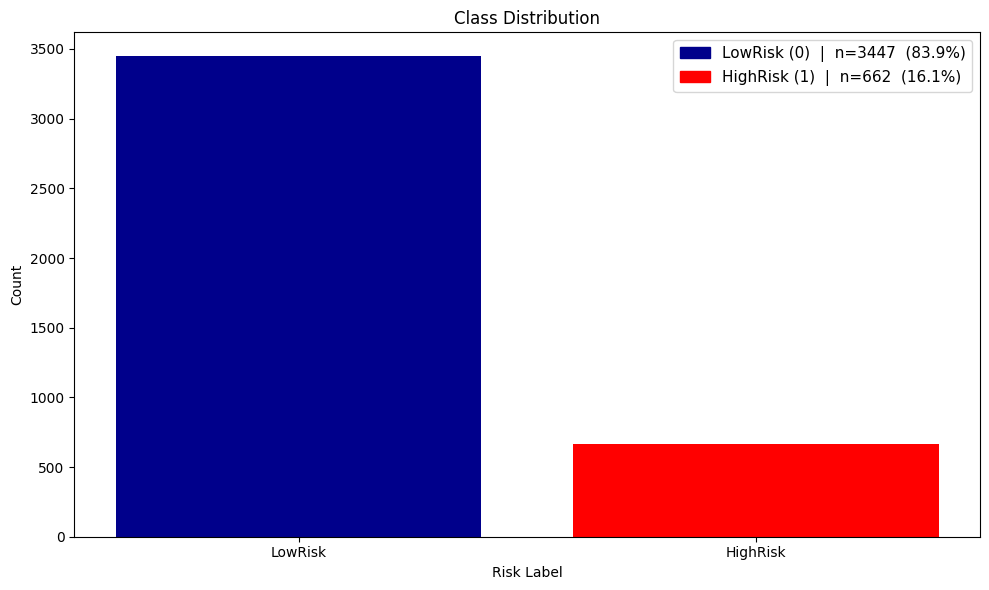

In [8]:
# 클래스 불균형 확인
counts = data['Risk_Label'].value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, 'grey') for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Risk Label')
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()


### **ADA**ptive **SYN**

In [9]:
# train 데이터에만 fit된 scaler 결과를 기준으로 ADASYN 적용
X = X_train_scaled.copy()

y_raw = y_train.copy()
if y_raw.dtype == object:
    y = y_raw.astype(str).str.strip().str.lower().map({'lowrisk': 0, 'highrisk': 1}).astype(int)
else:
    y = y_raw.astype(int)

adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=1,
    n_neighbors=5
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)


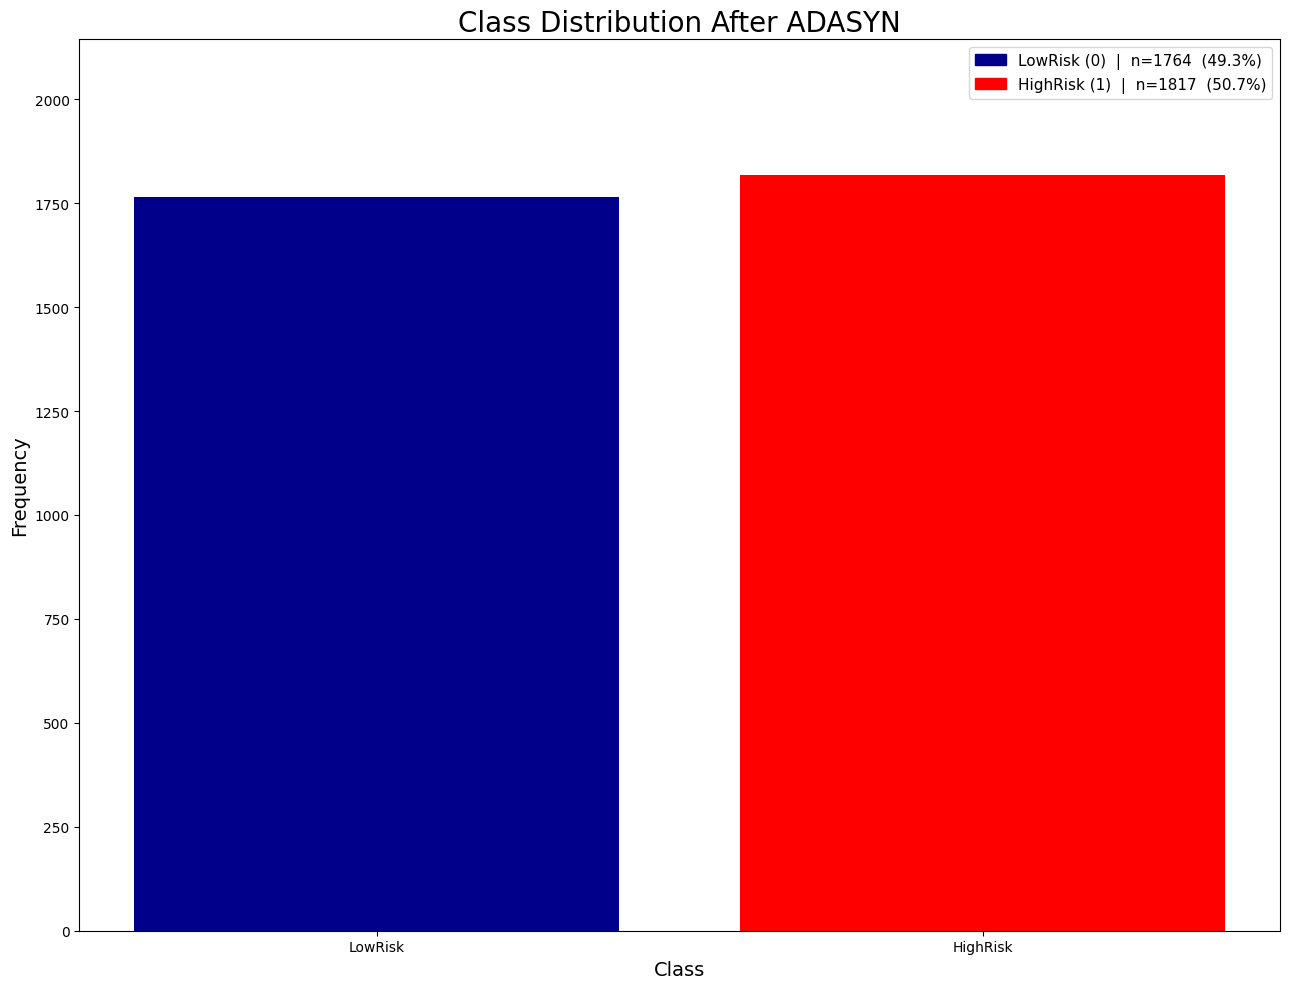

In [10]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()


In [11]:

# 4. train데이터 다시 데이터프레임으로 합치기
data_train_adasyn = X_resampled.copy()
data_train_adasyn['Risk_Label'] = data_train['Risk_Label'].iloc[0]  # 원래 train 데이터의 Risk_Label 컬럼에서 첫 번째 값으로 채우기
data_train_adasyn.head()


,GARCH_Vol,KOSDAQ,KOSPI 200 Low,Shanghai Comp,GJR_GARCH_Vol,GJR_VaR_95,Gold Spot,TOPIX,JPY/KRW,KOSPI 200 Close,NASDAQ,KODEX 200,Signal2_Sell,KOSPI 200_RSI14,Actual_Return(%),Risk_Label
0,0.354299,0.199014,0.016723,0.171840,0.293187,0.706813,0.000000,0.160470,0.677581,0.026426,0.013270,0.022549,0.0,0.622760,0.548072,0
1,0.330912,0.220831,0.012363,0.188488,0.276263,0.723737,0.019191,0.161448,0.702580,0.032694,0.000000,0.029739,0.0,0.755637,0.616220,0
2,0.310864,0.234903,0.003384,0.181760,0.252665,0.747335,0.014393,0.140900,0.731519,0.030497,0.007292,0.029739,0.0,0.739973,0.551119,0
3,0.289496,0.268970,0.030713,0.158592,0.238954,0.761046,0.023891,0.141879,0.731368,0.046262,0.007756,0.045098,0.0,0.730731,0.688352,0
4,0.291431,0.280201,0.043987,0.159403,0.216683,0.783317,0.037697,0.147750,0.715004,0.057505,0.009002,0.056863,0.0,0.687034,0.652799,0


In [12]:
# ======= [누더기 패치 + 검증] 저장 직전 =======

# ① train ADASYN: Risk_Label이 iloc[0] 하나로 잘못 채워졌으므로 y_resampled로 덮어쓰기
data_train_adasyn['Risk_Label'] = y_resampled.values

# ② valid / test: X_valid_scaled 에 Risk_Label 이미 붙어있지만
#    원본 slice 인덱스가 그대로라 reset 후 y_valid/y_test로 재조립 (인덱스 틀어짐 방지)
data_valid_scaled = X_valid_scaled.drop(columns=['Risk_Label'], errors='ignore').copy().reset_index(drop=True)
data_valid_scaled['Risk_Label'] = y_valid.reset_index(drop=True)

data_test_scaled = X_test_scaled.drop(columns=['Risk_Label'], errors='ignore').copy().reset_index(drop=True)
data_test_scaled['Risk_Label'] = y_test.reset_index(drop=True)

# ③ 검증
print("=== Risk_Label 분포 검증 ===")
print(f"[train ADASYN] {data_train_adasyn['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[valid]        {data_valid_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[test]         {data_test_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")

# 0/1 이외의 값이 끼어있으면 바로 터뜨리기
for name, df in [("train_adasyn", data_train_adasyn), ("valid", data_valid_scaled), ("test", data_test_scaled)]:
    bad = set(df['Risk_Label'].unique()) - {0, 1}
    assert not bad, f"[{name}] 이상한 Risk_Label 값 발견: {bad}"
print("✓ 모든 Risk_Label 정상 (0/1만 존재)")


=== Risk_Label 분포 검증 ===
[train ADASYN] {0: 1764, 1: 1817}
[valid]        {0: 1000, 1: 233}
[test]         {0: 683, 1: 139}
✓ 모든 Risk_Label 정상 (0/1만 존재)


In [13]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid_scaled.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test_scaled.to_csv('../../data/processed/ADASYN/data_test.csv', index=False)
